# Gravity removal with rotation matrix

Basic 3D rotations around each axis can be represented by pre-multiplying a column vector by a rotation matrix. If $\phi$ is the roll angle, $\theta$ is the pitch angle, and $\psi$ is the yaw angle, the rotation matrices for roll, pitch and yaw rotations are defined as follows:

$$
R_x(\phi) = \begin{bmatrix}
1 & 0 & 0 \\
0 & \cos\phi & -\sin\phi \\
0 & \sin\phi & \cos\phi
\end{bmatrix}
$$

$$
R_y(\theta) = \begin{bmatrix}
\cos\theta & 0 & \sin\theta \\
0 & 1 & 0 \\
-\sin\theta & 0 & \cos\theta
\end{bmatrix}
$$

$$
R_z(\psi) = \begin{bmatrix}
\cos\psi & -\sin\psi & 0 \\
\sin\psi & \cos\psi & 0 \\
0 & 0 & 1
\end{bmatrix}
$$

These matrices can be combined in different orders to represent a complete rotation in space. The order matters because matrix multiplication is not commutative. They also verify that: $ \bm{R}(\theta)^{-1} = \bm{R}(\theta)^T = \bm{R}(-\theta) $.

For this application, the gravity vector has to be expressed from the world frame into the body frame as follows:

$$
\bm{g_{body}} = \bm{R_{world\rightarrow body}} \cdot \bm{g_{world}}
$$

Keeping the same Euler convention used in the complementary filter, if the body-to-world rotation is written as $\bm{R_{body\rightarrow world}} = \bm{R_z(\psi)} \cdot \bm{R_y(\theta)} \cdot \bm{R_x(\phi)}$, then the world-to-body rotation is its inverse:

$$
\bm{R_{world\rightarrow body}} = \bm{R_{body\rightarrow world}}^{-1} = \bm{R_{body\rightarrow world}}^T = \bm{R_x(\phi)}^T \cdot \bm{R_y(\theta)}^T \cdot \bm{R_z(\psi)}^T = \bm{R_x(-\phi)} \cdot \bm{R_y(-\theta)} \cdot \bm{R_z(-\psi)}
$$

Using $\bm{g_{world}} = [0, 0, g]^T$ and noticing that yaw does not affect gravity compensation because rotations around the gravity axis leave $\bm{g_{world}}$ unchanged, the result is:

$$
\bm{g_{body}} = \begin{bmatrix}
- g\sin\theta \\
g\sin\phi\cos\theta \\
g\cos\phi\cos\theta
\end{bmatrix}
$$

Then it can be subtracted from the accelerometer readings to remove the gravity component:

$$
\bm{a_{body}} = \bm{a_{raw}} - \bm{g_{body}}
$$

Sources:
- <https://en.wikipedia.org/wiki/Rotation_matrix>


## Setup

In [25]:
from signal_utils import IMUSampleReader, IMUStationaryChecker
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

gridSearchDirectories = [
    "../3-orientation/output/ast=0.750-amv=0.950",
    "../3-orientation/output/ast=0.750-amv=0.975",
    "../3-orientation/output/ast=0.750-amv=0.990",
    "../3-orientation/output/ast=0.800-amv=0.950",
    "../3-orientation/output/ast=0.800-amv=0.975",
    "../3-orientation/output/ast=0.800-amv=0.990",
    "../3-orientation/output/ast=0.850-amv=0.950",
    "../3-orientation/output/ast=0.850-amv=0.975",
    "../3-orientation/output/ast=0.850-amv=0.990",
    "../3-orientation/output/ast=0.900-amv=0.950",
    "../3-orientation/output/ast=0.900-amv=0.975",
    "../3-orientation/output/ast=0.900-amv=0.990",
    "../3-orientation/output/ast=0.950-amv=0.950",
    "../3-orientation/output/ast=0.950-amv=0.975",
    "../3-orientation/output/ast=0.950-amv=0.990",
]

complementaryStationaryCaptures = [
    "positive-x-up-calibrated-complementary.csv",
    "negative-x-up-calibrated-complementary.csv",
    "positive-y-up-calibrated-complementary.csv",
    "negative-y-up-calibrated-complementary.csv",
    "positive-z-up-calibrated-complementary.csv",
    "negative-z-up-calibrated-complementary.csv",
]

simpleRotationsCaptures = [
    "rotation-x-hw-complementary.csv",
    "rotation-y-hw-complementary.csv",
    "rotation-z-hw-complementary.csv",
]

realExerciseCaptures = [
    "dips-1-complementary.csv",
    "dips-2-complementary.csv",
    "dips-3-complementary.csv",
    "pull-ups-1-complementary.csv",
    "pull-ups-2-complementary.csv",
    "pull-ups-3-complementary.csv",
    "90-deg-push-ups-1-complementary.csv",
    "90-deg-push-ups-2-complementary.csv",
]

calibratedStationaryCaptures = [
    "../1-calibration/output/positive-x-up-calibrated.csv",
    "../1-calibration/output/negative-x-up-calibrated.csv",
    "../1-calibration/output/positive-y-up-calibrated.csv",
    "../1-calibration/output/negative-y-up-calibrated.csv",
    "../1-calibration/output/positive-z-up-calibrated.csv",
    "../1-calibration/output/negative-z-up-calibrated.csv",
]
stationaryChecker = IMUStationaryChecker()
stationaryChecker.computeTolerances(calibratedStationaryCaptures)

reader = IMUSampleReader()


def mergeDirectoryWithCaptures(directory: str, captures: list) -> list:
    result = []
    for capture in captures:
        result.append(f"{directory}/{capture}")
    return result

Acceleration norms:	Mean = 9.806204
	Stdev = 0.040047
	Stationary tol = 0.200234
Gyroscope norms: 	Stdev = 2.590542
	Stationary tol = 7.771626


## Computation

In [26]:
G_WORLD = np.array([0, 0, 9.81])


def subtractGravity(a, angle):
    RBodyWorld = getBodyToWorldRotationMatrices(angle[:, 0], angle[:, 1], angle[:, 2])
    RWorldBody = np.transpose(RBodyWorld, (0, 2, 1))
    return a - RWorldBody @ G_WORLD


def getBodyToWorldRotationMatrices(rolls, pitches, yaws):
    n = len(rolls)

    rollsRad = np.radians(rolls)
    pitchesRad = np.radians(pitches)
    yawsRad = np.radians(yaws)

    Rx = np.zeros((n, 3, 3))
    rollsCos = np.cos(rollsRad)
    rollsSin = np.sin(rollsRad)
    Rx[:, 0, 0] = 1
    Rx[:, 1, 1] = rollsCos
    Rx[:, 1, 2] = -rollsSin
    Rx[:, 2, 1] = rollsSin
    Rx[:, 2, 2] = rollsCos

    Ry = np.zeros((n, 3, 3))
    pitchesCos = np.cos(pitchesRad)
    pitchesSin = np.sin(pitchesRad)
    Ry[:, 0, 0] = pitchesCos
    Ry[:, 0, 2] = pitchesSin
    Ry[:, 1, 1] = 1
    Ry[:, 2, 0] = -pitchesSin
    Ry[:, 2, 2] = pitchesCos

    Rz = np.zeros((n, 3, 3))
    yawsCos = np.cos(yawsRad)
    yawsSin = np.sin(yawsRad)
    Rz[:, 0, 0] = yawsCos
    Rz[:, 0, 1] = -yawsSin
    Rz[:, 1, 0] = yawsSin
    Rz[:, 1, 1] = yawsCos
    Rz[:, 2, 2] = 1

    return Rz @ Ry @ Rx

## Histograms for one $(\alpha_{stationary}, \alpha_{moving})$ pair

In [27]:
def plotGravitySubstractionHistograms(captures):
    cols = 3
    rows = (len(captures) + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, squeeze=False, figsize=(5 * cols, 5 * rows))
    fig.suptitle("Gravity-free acceleration norm histograms")

    residualsMemo = {}
    areStationaryMemo = {}

    # Cache residuals and stationary flags compute 97.5th percentile
    residuals = []
    for capture in captures:
        _, a, w, angle = reader.readFiltered(capture)
        residualsMemo[capture] = np.linalg.norm(subtractGravity(a, angle), axis=1)
        areStationaryMemo[capture] = stationaryChecker.areStationarySamples(a, w)
        residuals.append((residualsMemo[capture]))
    globalP975 = np.percentile(np.concatenate(residuals), 97.5)

    for k, capture in enumerate(captures):
        i = k // cols
        j = k % cols

        stationaryResiduals = [
            residual
            for residual, isStationary in zip(
                residualsMemo[capture], areStationaryMemo[capture]
            )
            if isStationary
        ]
        movingResiduals = [
            residual
            for residual, isStationary in zip(
                residualsMemo[capture], areStationaryMemo[capture]
            )
            if not isStationary
        ]

        plotResidualsHistograms(
            axes[i, j],
            stationaryResiduals,
            movingResiduals,
            0,
            globalP975,
            capture,
        )

    # Remove any unused subplots
    for k in range(len(captures), rows * cols):
        fig.delaxes(axes[k // cols, k % cols])

    plt.tight_layout(rect=(0, 0, 1, 0.985))
    plt.show()


def plotResidualsHistograms(
    axis, stationaryResiduals, movingResiduals, minVal, maxVal, title
):

    axis.set_title(title, fontsize=8)
    axis.set_xlabel("Residual (m/s^2)")
    axis.set_xlim(minVal, maxVal)
    axis.set_ylabel("Frequency")

    stationaryN = len(stationaryResiduals)
    stationaryMean = np.mean(stationaryResiduals)
    stationaryStd = np.std(stationaryResiduals)
    if stationaryN > 0:

        axis.hist(
            stationaryResiduals, bins=20, color="blue", alpha=0.6, label="Stationary"
        )
        axis.axvline(
            stationaryMean,
            color="blue",
            linestyle="dashed",
            linewidth=2,
            label=f"mean(stationary) = {stationaryMean:.3f}",
        )
        axis.plot(
            [],
            [],
            linestyle="",
            label=f"std(stationary) = {stationaryStd:.3f}",
        )
        axis.plot(
            [],
            [],
            linestyle="",
            label=f"n(stationary) = {stationaryN}",
        )

    movingN = len(movingResiduals)
    movingMean = np.mean(movingResiduals)
    movingStd = np.std(movingResiduals)
    if movingN > 0:

        axis.hist(movingResiduals, bins=20, color="red", alpha=0.6, label="Moving")
        axis.axvline(
            movingMean,
            color="red",
            linestyle="dashed",
            linewidth=2,
            label=f"mean(moving) = {movingMean:.3f}",
        )
        axis.plot([], [], linestyle="", label=f"std(moving) = {movingStd:.3f}")
        axis.plot([], [], linestyle="", label=f"n(moving) = {movingN}")

        if stationaryN > 0:
            axis.plot(
                [],
                [],
                linestyle="",
                label=f"mean diff = {movingMean - stationaryMean:.3f}",
            )
            axis.plot(
                [],
                [],
                linestyle="",
                label=f"mean ratio = {movingMean / stationaryMean:.3f}",
            )

    axis.legend()
    axis.grid()

## Sanity check: stationary

When the device is stationary, the norm of the resulting acceleration vector should resemble a normal distribution with a mean close to 0 and variance due to sensor noise. This is consistent with has been seen in the [analysis](../1-calibration/2-analysis.ipynb) of sensor data to calibrate the device. Notice that some symmetry may be lost since the norm is always non-negative. 

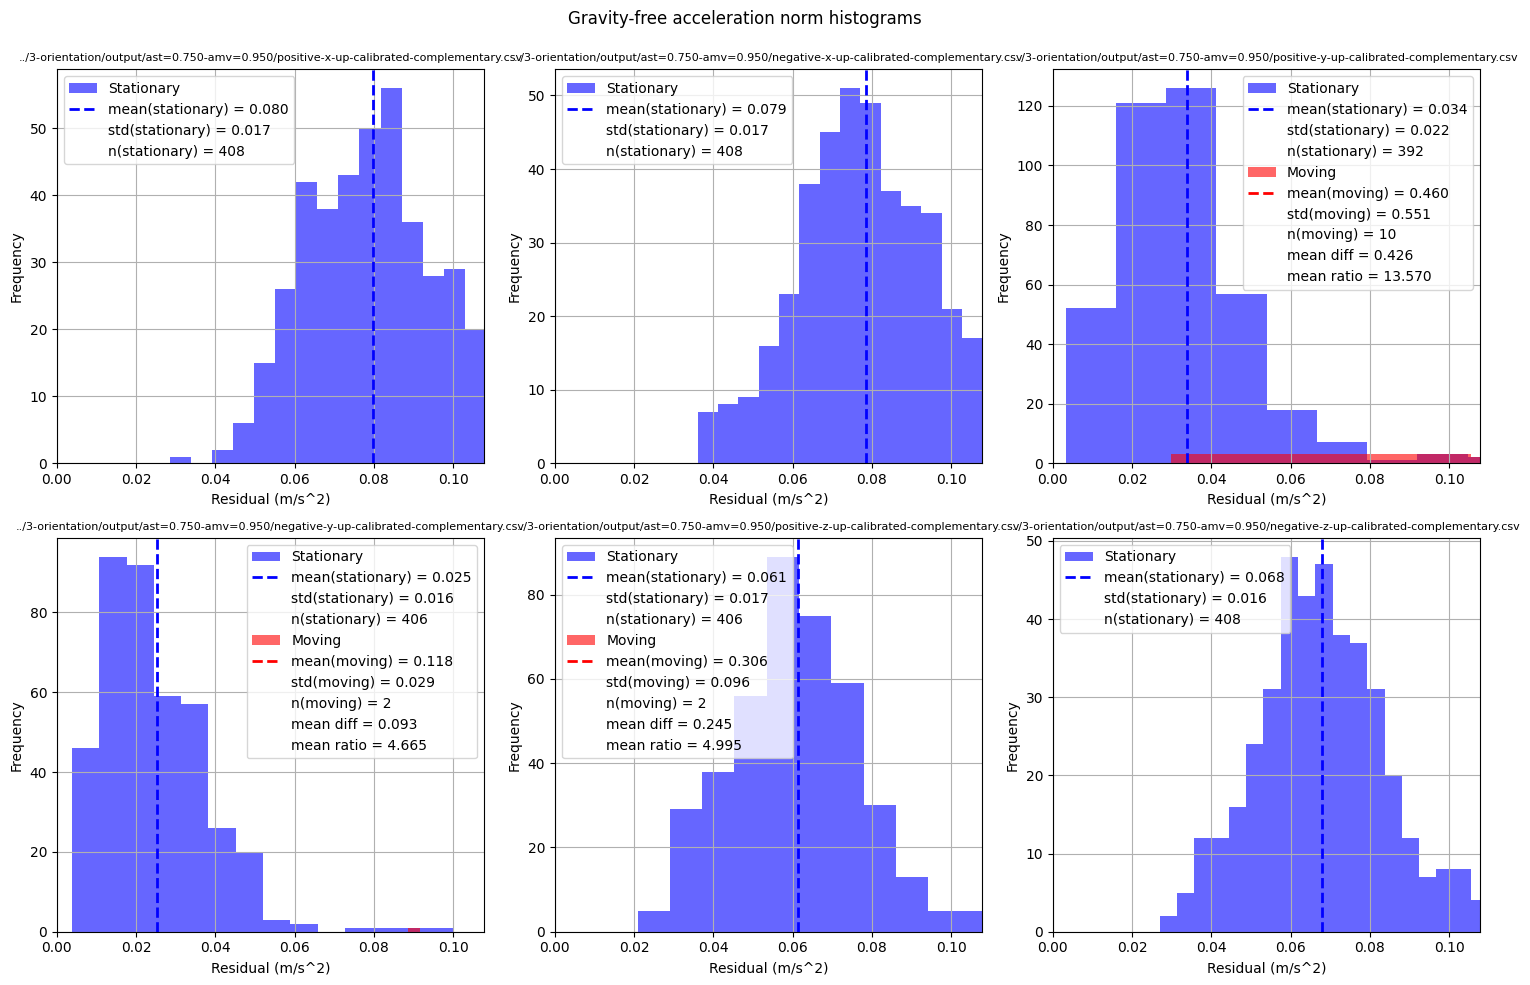

In [28]:
plotGravitySubstractionHistograms(
    mergeDirectoryWithCaptures(
        gridSearchDirectories[0], complementaryStationaryCaptures
    )
)

## Simple rotations

As stated in the [protocol](../3-orientation/1-dataCapture.ipynb) for the capture of simple rotations, the device is rotated around one axis at a time, interleaving brief pauses. When the device is stationary, it should resemble what was seen in the previous section. When it's moving, it should produce another approximately normal distribution to the right of the stationary distribution, but with relatively low mean since movements were performed in a controlled manner.


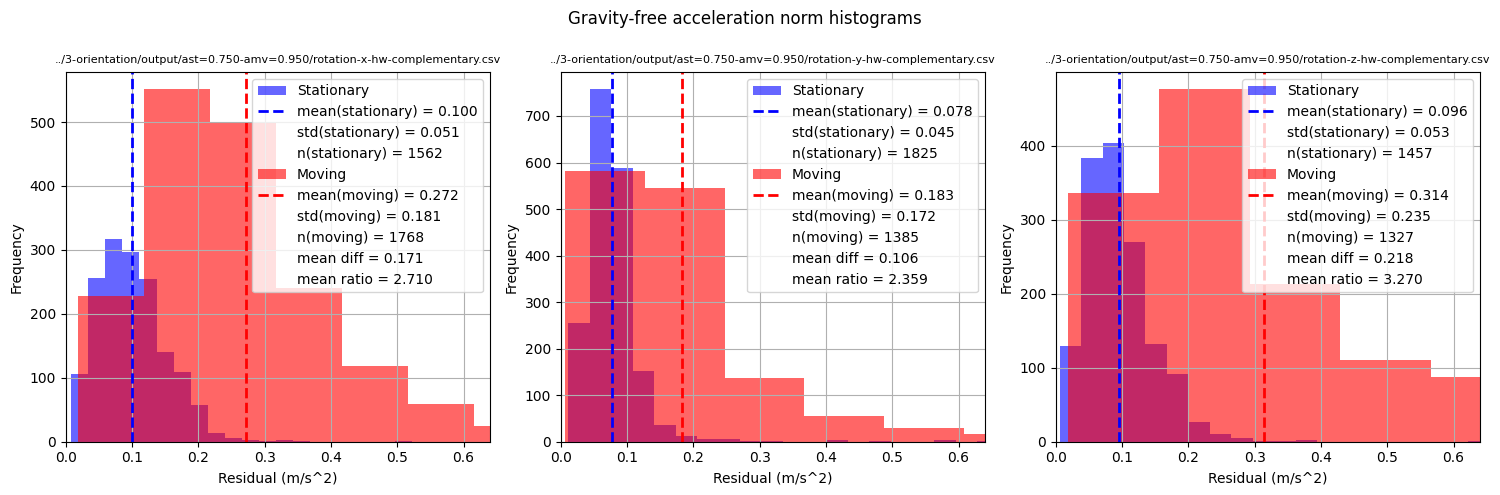

In [29]:
plotGravitySubstractionHistograms(
    mergeDirectoryWithCaptures(gridSearchDirectories[0], simpleRotationsCaptures)
)

## Real exercises

Real exercises are more complex, since the device may be rotated around multiple axes at the same time, changes position, and moves fast. 

Finding a suitable pair of $(\alpha_{stationary}, \alpha_{moving})$ values for the complementary filter is needed. A grid search was performed on the [complementary filter notebook](../3-orientation/2-complementaryFilter.ipynb), and here a pair is chosen to:
* Minimize the global mean of stationary acceleration norms: brief stationary intervals should show similar values to those of calibration captures.
* Maximize the difference between the average means of the stationary and moving acceleration norms: to achieve statistical significance, means should be as separated as possible.  
* Maximize the ratio between the average means of the stationary and moving acceleration norms: stationary means should be as small as possible relative to moving means.
* Maximize the correlation between raw acceleration and gravity-free acceleration: the faster the device moves, the greater should the gravity-free acceleration norm be and viceversa.


In [30]:
def computeMetrics():
    print("Gravity-free norms metrics:")
    for i, directory in enumerate(gridSearchDirectories):
        stationaryResiduals = []
        movingResiduals = []
        pearsonRs = []
        spearmanRs = []
        print(f"\tDirectory: {directory} (directoryIdx = {i})")
        for capture in mergeDirectoryWithCaptures(directory, realExerciseCaptures):
            _, a, w, angle = reader.readFiltered(capture)
            captureResiduals = np.linalg.norm(subtractGravity(a, angle), axis=1)
            captureStationalityFlags = stationaryChecker.areStationarySamples(a, w)
            captureStationaryResiduals = np.array(
                [
                    residual
                    for residual, isStationary in zip(
                        captureResiduals, captureStationalityFlags
                    )
                    if isStationary
                ]
            )
            captureMovingResiduals = np.array(
                [
                    residual
                    for residual, isStationary in zip(
                        captureResiduals, captureStationalityFlags
                    )
                    if not isStationary
                ]
            )

            captureRawAccelDeviations = np.abs(
                np.linalg.norm(a, axis=1) - stationaryChecker.g
            )
            pearsonRs.append(
                stats.pearsonr(captureRawAccelDeviations, captureResiduals)[0]
            )
            spearmanRs.append(
                stats.spearmanr(captureRawAccelDeviations, captureResiduals)[0]
            )

            stationaryResiduals.append(captureStationaryResiduals)
            movingResiduals.append(captureMovingResiduals)
        stationaryResiduals = np.concatenate(stationaryResiduals)
        movingResiduals = np.concatenate(movingResiduals)

        print(f"\t\tResiduals:")
        print(f"\t\t\tGlobal stationary mean: {np.mean(stationaryResiduals):.6f}")
        print(f"\t\t\tGlobal moving mean: {np.mean(movingResiduals):.6f}")
        print(
            f"\t\t\tGlobal mean difference: {np.mean(movingResiduals) - np.mean(stationaryResiduals):.6f}"
        )
        print(
            f"\t\t\tGlobal mean ratio: {np.mean(movingResiduals) / np.mean(stationaryResiduals):.6f}"
        )

        print("\t\tCorrelation (stationary + moving):")
        print(f"\t\t\tPearson: {np.mean(pearsonRs):.6f}")
        print(
            f"\t\t\t\tMin: {np.min(pearsonRs):.6f} (captureIdx = {np.argmin(pearsonRs)})"
        )
        print(f"\t\t\t\tMean: {np.mean(pearsonRs):.6f}")
        print(
            f"\t\t\t\tMax: {np.max(pearsonRs):.6f} (captureIdx = {np.argmax(pearsonRs)})"
        )

        print(f"\t\t\tSpearman: {np.mean(spearmanRs):.6f}")
        print(
            f"\t\t\t\tMin: {np.min(spearmanRs):.6f} (captureIdx = {np.argmin(spearmanRs)})"
        )
        print(f"\t\t\t\tMean: {np.mean(spearmanRs):.6f}")
        print(
            f"\t\t\t\tMax: {np.max(spearmanRs):.6f} (captureIdx = {np.argmax(spearmanRs)})"
        )

        print("\n")


computeMetrics()

Gravity-free norms metrics:
	Directory: ../3-orientation/output/ast=0.750-amv=0.950 (directoryIdx = 0)
		Residuals:
			Global stationary mean: 0.282498
			Global moving mean: 1.903260
			Global mean difference: 1.620762
			Global mean ratio: 6.737251
		Correlation (stationary + moving):
			Pearson: 0.901466
				Min: 0.836580 (captureIdx = 1)
				Mean: 0.901466
				Max: 0.966324 (captureIdx = 3)
			Spearman: 0.815704
				Min: 0.735754 (captureIdx = 1)
				Mean: 0.815704
				Max: 0.912495 (captureIdx = 5)


	Directory: ../3-orientation/output/ast=0.750-amv=0.975 (directoryIdx = 1)
		Residuals:
			Global stationary mean: 0.294918
			Global moving mean: 1.952240
			Global mean difference: 1.657322
			Global mean ratio: 6.619602
		Correlation (stationary + moving):
			Pearson: 0.892004
				Min: 0.806618 (captureIdx = 1)
				Mean: 0.892004
				Max: 0.963928 (captureIdx = 3)
			Spearman: 0.798282
				Min: 0.680203 (captureIdx = 1)
				Mean: 0.798282
				Max: 0.908320 (captureIdx = 5)


	Direc

### Histograms

Choose a suitable pair of $(\alpha_{stationary}, \alpha_{moving})$ values from the output above and use it to select a directory with filtered captures to analyze.

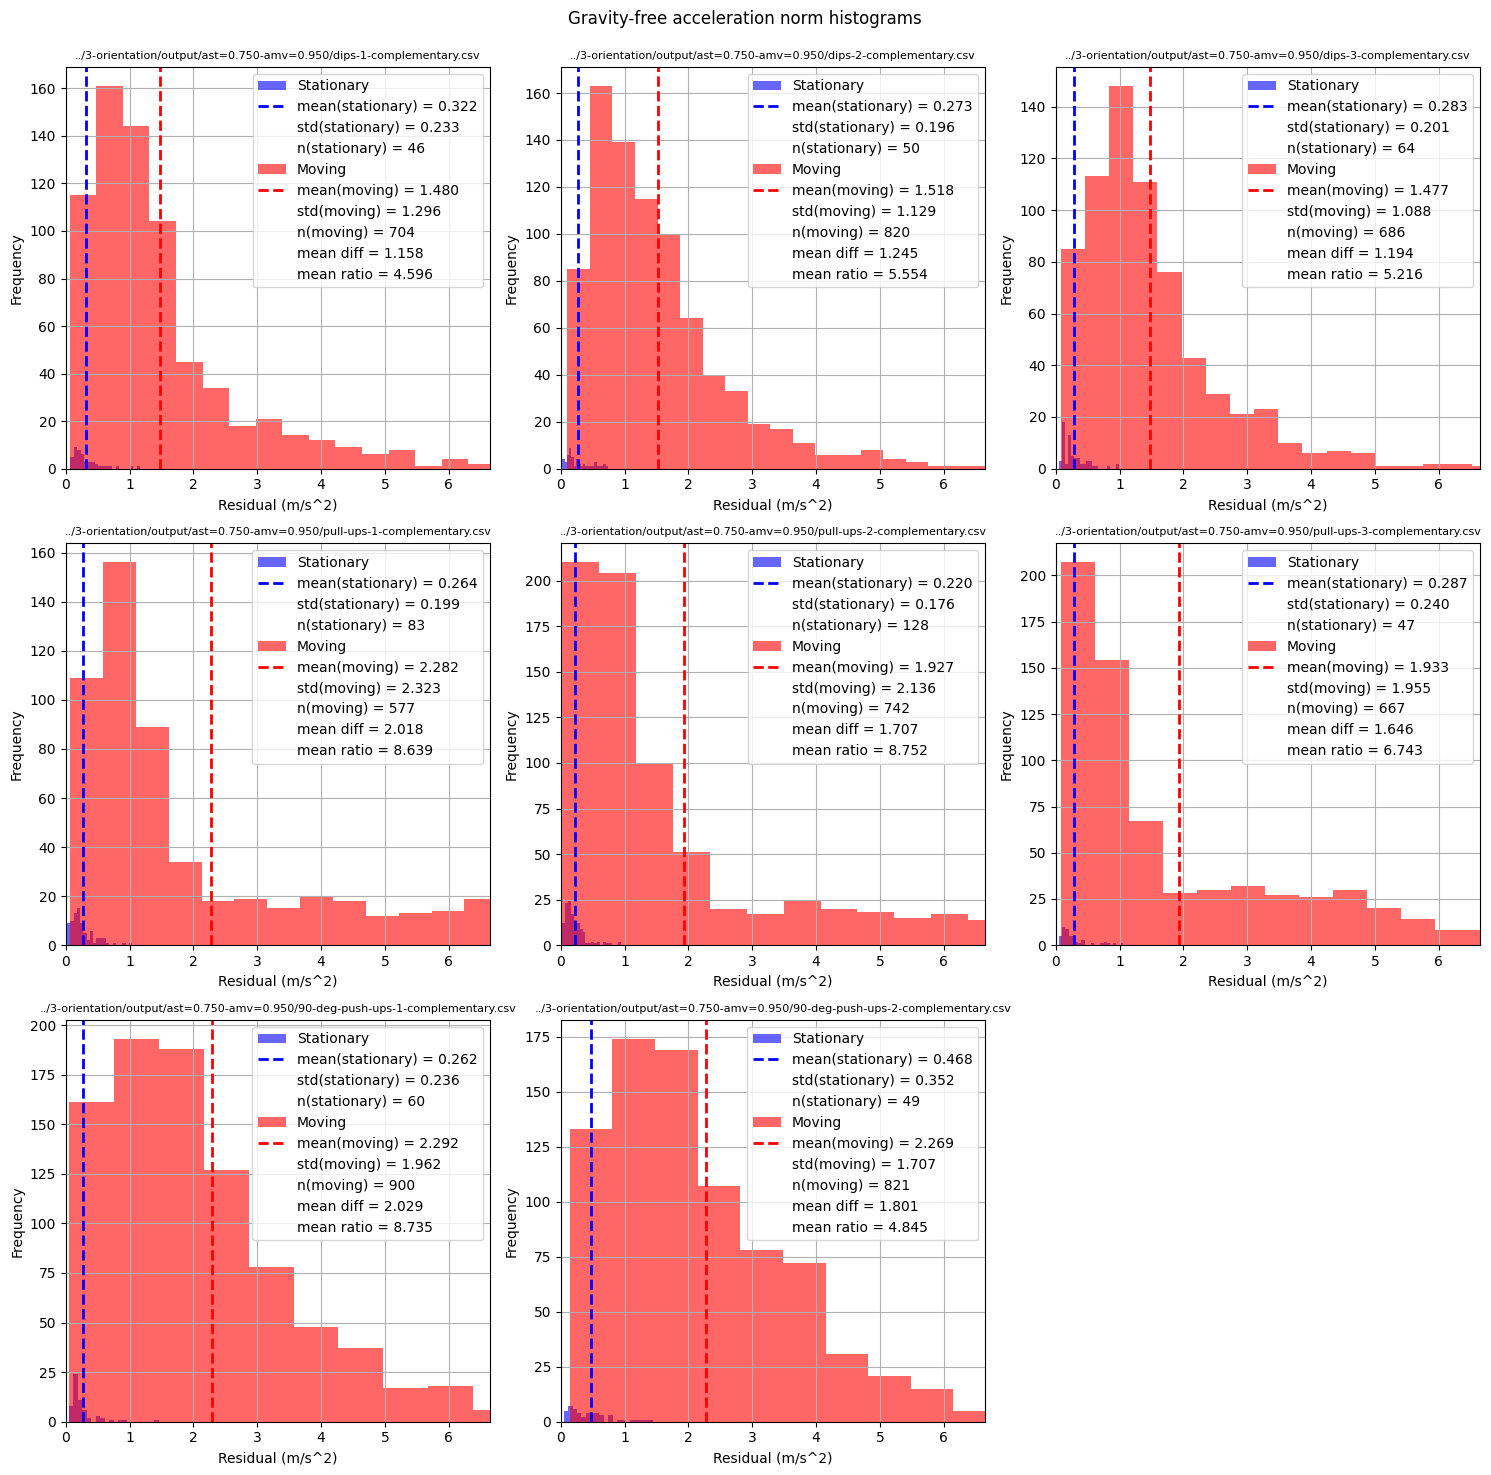

In [31]:
DIRECTORY_IDX = 0
plotGravitySubstractionHistograms(
    mergeDirectoryWithCaptures(
        gridSearchDirectories[DIRECTORY_IDX], realExerciseCaptures
    )
)

# Time series of norms

For captures with high stationary means relative to the others, inspect the time series graph of raw and gravity-free acceleration norms closer. Also compare against angle graphs from the complementary filter notebook. 

General properties:

* When the raw signal is close to $g$, the other one should be close to 0. 
* The norm is strictly non-negative, so when the raw signal exhibits a valley, the gravity-free signal should exhibit a peak. 
* Exercise repetitions should be possible to identify in the gravity-free signal. 
* Amplitudes need not to be the same. 
* Both signals should not have big phase differences. 

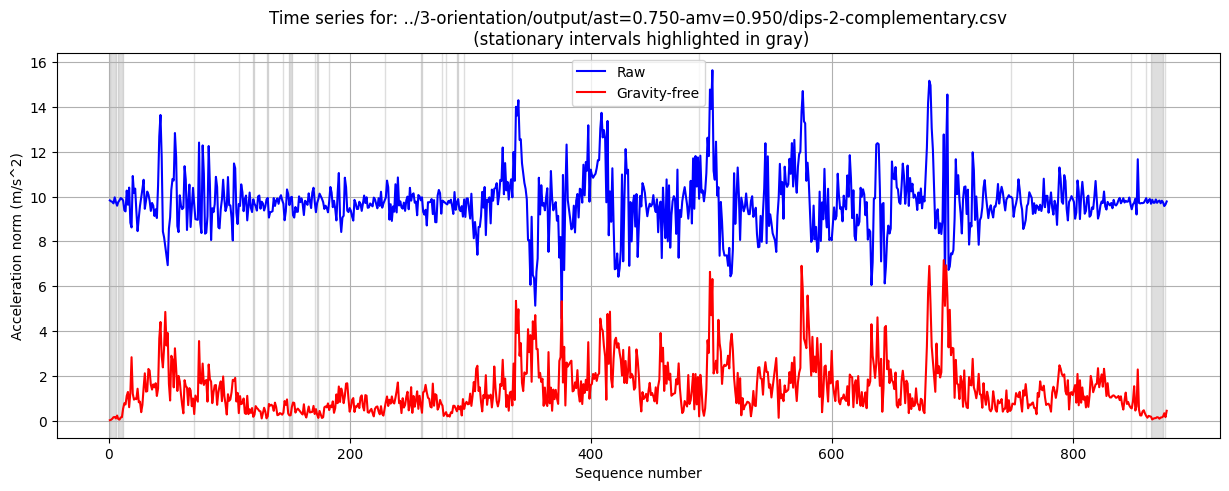

In [ ]:
CAPTURE_IDX = 1
chosenCapture = mergeDirectoryWithCaptures(
    gridSearchDirectories[DIRECTORY_IDX], realExerciseCaptures
)[CAPTURE_IDX]
seq, a, w, angle = reader.readFiltered(chosenCapture)
rawAccelNorm = np.linalg.norm(a, axis=1)
gravityFreeAccelNorm = np.linalg.norm(subtractGravity(a, angle), axis=1)
stationaryIntervals = stationaryChecker.findStationaryIntervals(seq, a, w)

fig, axis = plt.subplots(figsize=(15, 5))
axis.plot(seq, rawAccelNorm, label="Raw", color="blue")
axis.plot(seq, gravityFreeAccelNorm, label="Gravity-free", color="red")
axis.set_title(
    f"Time series for: {chosenCapture}\n (stationary intervals highlighted in gray)"
)
axis.set_xlabel("Sequence number")
axis.set_ylabel("Acceleration norm (m/s^2)")
for lower, upper in stationaryIntervals:
    axis.axvspan(lower, upper, color="tab:gray", alpha=0.25, zorder=0)
axis.legend()
axis.grid()
plt.show()

### Scatter plots

Points should follow a functional relationship, either linear or non-linear, instead of being a random cloud of points. Both Pearson and Spearman correlation coefficients are considered. These should be as close to 1 as possible.

Sources:
* https://www.youtube.com/watch?v=k7IctLRiZmo
* https://www.youtube.com/watch?v=XV_W1w4Nwoc
* https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.pearsonr.html
* https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.rankdata.html
* https://en.wikipedia.org/wiki/Ranking
* https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.spearmanr.html#scipy.stats.spearmanr

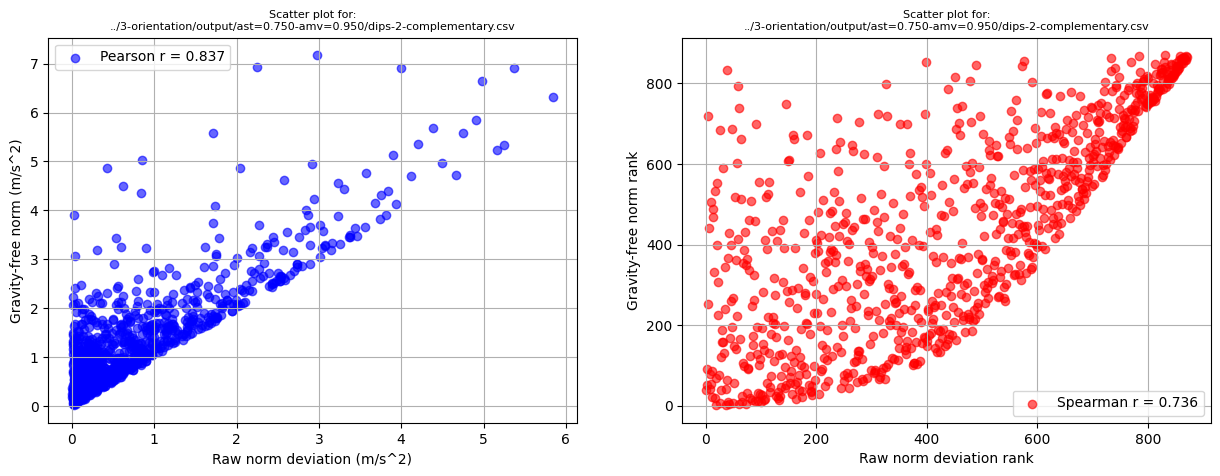

In [33]:
stationaryMask = stationaryChecker.areStationarySamples(a, w)
rawAccelDeviation = np.abs(rawAccelNorm - stationaryChecker.g)
pearsonR = stats.pearsonr(rawAccelDeviation, gravityFreeAccelNorm)[0]

rawAccelNormRanks = stats.rankdata(rawAccelDeviation, method="average")
gravityFreeAccelNormRanks = stats.rankdata(gravityFreeAccelNorm, method="average")
spearmanR = stats.spearmanr(rawAccelDeviation, gravityFreeAccelNorm)[0]

fig, axis = plt.subplots(1, 2, figsize=(15, 5))
axis[0].set_title(f"Scatter plot for:\n{chosenCapture}", fontsize=8)
axis[0].scatter(
    rawAccelDeviation,
    gravityFreeAccelNorm,
    c="blue",
    alpha=0.6,
)
axis[0].scatter([], [], c="blue", alpha=0.6, label=f"Pearson r = {pearsonR:.3f}")
axis[0].set_xlabel("Raw norm deviation (m/s^2)")
axis[0].set_ylabel("Gravity-free norm (m/s^2)")
axis[0].legend()
axis[0].grid()

axis[1].set_title(f"Scatter plot for:\n{chosenCapture}", fontsize=8)
axis[1].scatter(
    rawAccelNormRanks,
    gravityFreeAccelNormRanks,
    c="red",
    alpha=0.6,
)
axis[1].scatter([], [], c="red", alpha=0.6, label=f"Spearman r = {spearmanR:.3f}")
axis[1].set_xlabel("Raw norm deviation rank")
axis[1].set_ylabel("Gravity-free norm rank")
axis[1].legend()
axis[1].grid()

plt.show()

## Conclusion

For the pair $(\alpha_{stationary}, \alpha_{moving}) = (0.75, 0.95)$ the results are good given the relatively simple filter and the cheap IMU used:
* Relatively low stationary mean of 0.28 m/s², about 2.85% of $g$. Worst case: 2nd 90 degree push ups capture with 0.47m/s², about 4.79% of $g$. Still, about an order of magnitude worse than pure stationary captures. 
* Correlation coefficients are relatively high, with Pearson's $r$ around 0.90 and Spearman's $\rho$ around 0.82. Worse case: 1st dip capture with 0.84 and 0.74 respectively, still high-ish.
* Visual inspection of graphs look fine for all exercise captures. 